In [1]:
import numpy as np
import matplotlib.pyplot as plt
from astropy.table import Table, vstack
import fitsio

In [2]:
elgtable = []
lrgtable = []
for i in range(18):
    eNfile = '/global/cfs/cdirs/desi/vac/edr/lss/v2.0/LSScats/clustering/ELG_N_'+str(i)+'_clustering.ran.fits'
    eSfile = '/global/cfs/cdirs/desi/vac/edr/lss/v2.0/LSScats/clustering/ELG_S_'+str(i)+'_clustering.ran.fits'
    lNfile = '/global/cfs/cdirs/desi/vac/edr/lss/v2.0/LSScats/clustering/LRG_N_'+str(i)+'_clustering.ran.fits'
    lSfile = '/global/cfs/cdirs/desi/vac/edr/lss/v2.0/LSScats/clustering/LRG_S_'+str(i)+'_clustering.ran.fits'
    speN = Table(fitsio.read(eNfile))
    speS = Table(fitsio.read(eSfile))
    splN = Table(fitsio.read(lNfile))
    splS = Table(fitsio.read(lSfile))
    elgtable.append(speN)
    elgtable.append(speS)
    lrgtable.append(splN)
    lrgtable.append(splS)
elg = vstack(elgtable)
lrg = vstack(lrgtable)

Text(0.5, 1.0, 'ELG Distribution in 18 Combined Random LSS SV3 Catalogs')

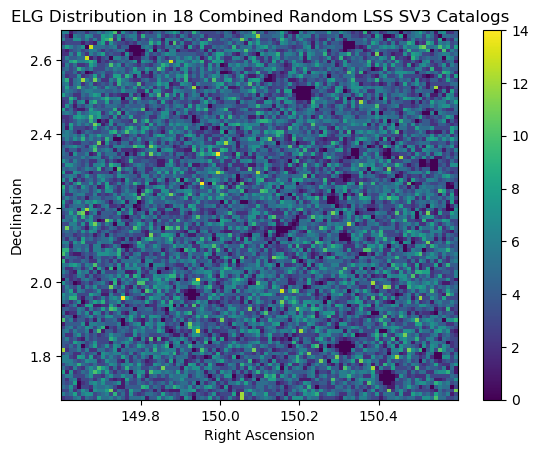

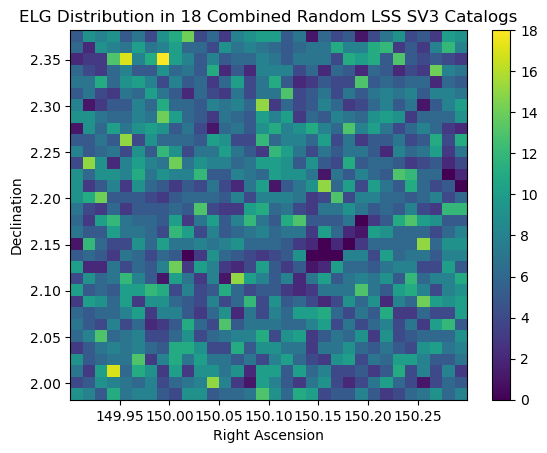

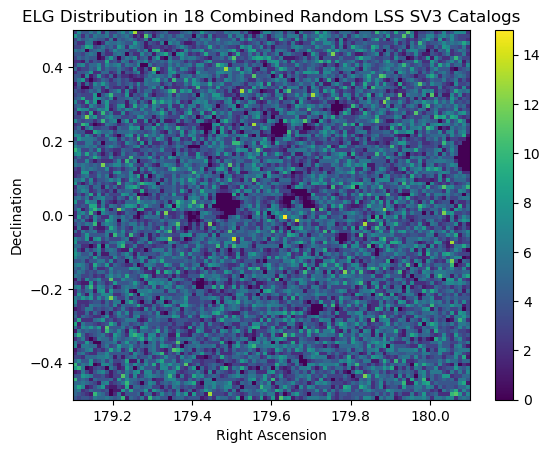

In [3]:
#we are looking for holes on the scale of 0.05 deg
#let's just make some histograms around the equator
ra1 = 150.1
dec1 = 2.182
elgreg1 = elg[(elg['RA'] > ra1-0.5)&(elg['RA']<ra1+0.5)&(elg['DEC']>dec1-0.5)&(elg['DEC']<dec1+0.5)]
hist1,binsx,binsy = np.histogram2d(elgreg1['RA'],elgreg1['DEC'],bins=100)
fig, ax = plt.subplots(1)
pc = ax.pcolormesh(binsx,binsy,hist1)
cbar = plt.colorbar(pc)
plt.xlabel("Right Ascension")
plt.ylabel("Declination")
plt.title("ELG Distribution in 18 Combined Random LSS SV3 Catalogs")


#zoomed in version
ra1 = 150.1
dec1 = 2.182
elgreg1 = elg[(elg['RA'] > ra1-0.2)&(elg['RA']<ra1+0.2)&(elg['DEC']>dec1-0.2)&(elg['DEC']<dec1+0.2)]
hist1,binsx,binsy = np.histogram2d(elgreg1['RA'],elgreg1['DEC'],bins=32)
fig, ax = plt.subplots(1)
pc = ax.pcolormesh(binsx,binsy,hist1)
cbar = plt.colorbar(pc)
plt.xlabel("Right Ascension")
plt.ylabel("Declination")
plt.title("ELG Distribution in 18 Combined Random LSS SV3 Catalogs")

ra1 = 179.6
dec1 = 0
elgreg1 = elg[(elg['RA'] > ra1-0.5)&(elg['RA']<ra1+0.5)&(elg['DEC']>dec1-0.5)&(elg['DEC']<dec1+0.5)]
hist1,binsx,binsy = np.histogram2d(elgreg1['RA'],elgreg1['DEC'],bins=100)
fig, ax = plt.subplots(1)
pc = ax.pcolormesh(binsx,binsy,hist1)
cbar = plt.colorbar(pc)
plt.xlabel("Right Ascension")
plt.ylabel("Declination")
plt.title("ELG Distribution in 18 Combined Random LSS SV3 Catalogs")

In [20]:
def binomialP(N, k):
    #nexp is the expectation CiC
    #k is the measured CiC whose probability you're querying
    if k == 0:
        return np.exp(-N)
    else:
        product = 1
        for i in np.arange(1,k+1):
            product = product * N / i
        p = product*np.exp(-N)
        return p

mean count in (0.05 deg)^2 cell: 4.2998


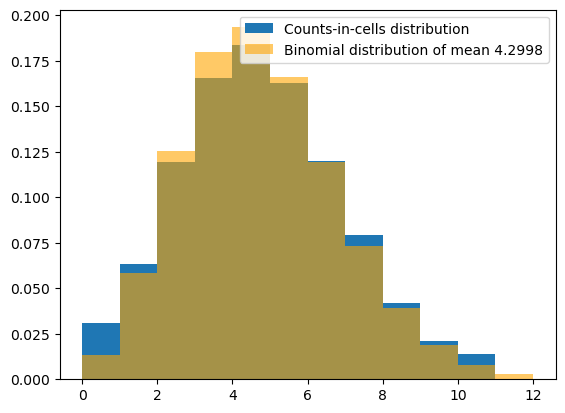

In [21]:
histlist = hist1.flatten().flatten()
N = np.average(histlist)
print("mean count in (0.05 deg)^2 cell: "+str(N))
plt.figure()
plt.hist(histlist, density=True,bins=np.arange(12),label = "Counts-in-cells distribution")
x = np.arange(12)
px = [binomialP(N,x_i) for x_i in x]
plt.bar(x,px,color='orange',align='edge',width=1,alpha=0.6,label='Binomial distribution of mean '+str(N))
plt.legend()

In [12]:
print(len(histlist))

10000
